# Scattering Transform on HEALPix Patches

This notebook demonstrates the application of the 2D Wavelet Scattering Transform to HEALPix map patches. It covers:
1. Setting up the filter bank (Morlet, Gabor, Bump wavelets) and plotting them.
2. Discussing the applicability of different filters.
3. Loading and decomposing a portion of the Planck PR3 353 GHz map into overlapping square patches.
4. Computing the 2D Scattering Coefficients using our JAX-accelerated pipeline.
5. Visualizing the scattering coefficient maps ($S_0$, $S_1$, $S_2$).

In [1]:
import os
import sys
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
import cmocean as cmo
import jax.numpy as jnp

# Automatically reload imported modules when they change on disk
%load_ext autoreload
%autoreload 2

# Set up local imports from the codebase
import skykit.healpix_tiling as tl
from skykit.jax_wavelets import generate_filter_bank
from skykit.scattering_transform import Scattering2D
from skykit.tile_plotting import plot_scattering_coefs

%matplotlib inline
plt.rcParams['figure.dpi'] = 150

## 1. Define and Visualize Wavelet Filter Banks

The wavelet scattering transform builds an image feature representation by cascading wavelet convolutions and non-linear modulus operators. The `generate_filter_bank` function generates the required family of Morlet, Gabor, or Bump wavelets across multiple scales $J$ and orientations $L$.

### Filter Choice Application
1. **Morlet Wavelet**: The default in Kymatio and standard feature-extraction pipelines. It ensures accurate separation of signal at multiple rotational bands while removing the DC-bias from the Gabor Gaussian plane-wave component. Great for general-purpose filament and orientation discovery on diffuse fields (e.g. general ISM dust emission).
2. **Bump Wavelets**: Compactly supported in Fourier space, creating well-defined frequency tiles. Ideal when avoiding cross-talk between tight frequencies is strictly required. 
3. **Gabor Wavelet**: The standard complex Gaussian-modulated sinusoid.

Let's visualize the Fourier-space filters defined by $\phi$ (lowpass) and $\psi_{j, \theta}$ (bandpass wavelets).

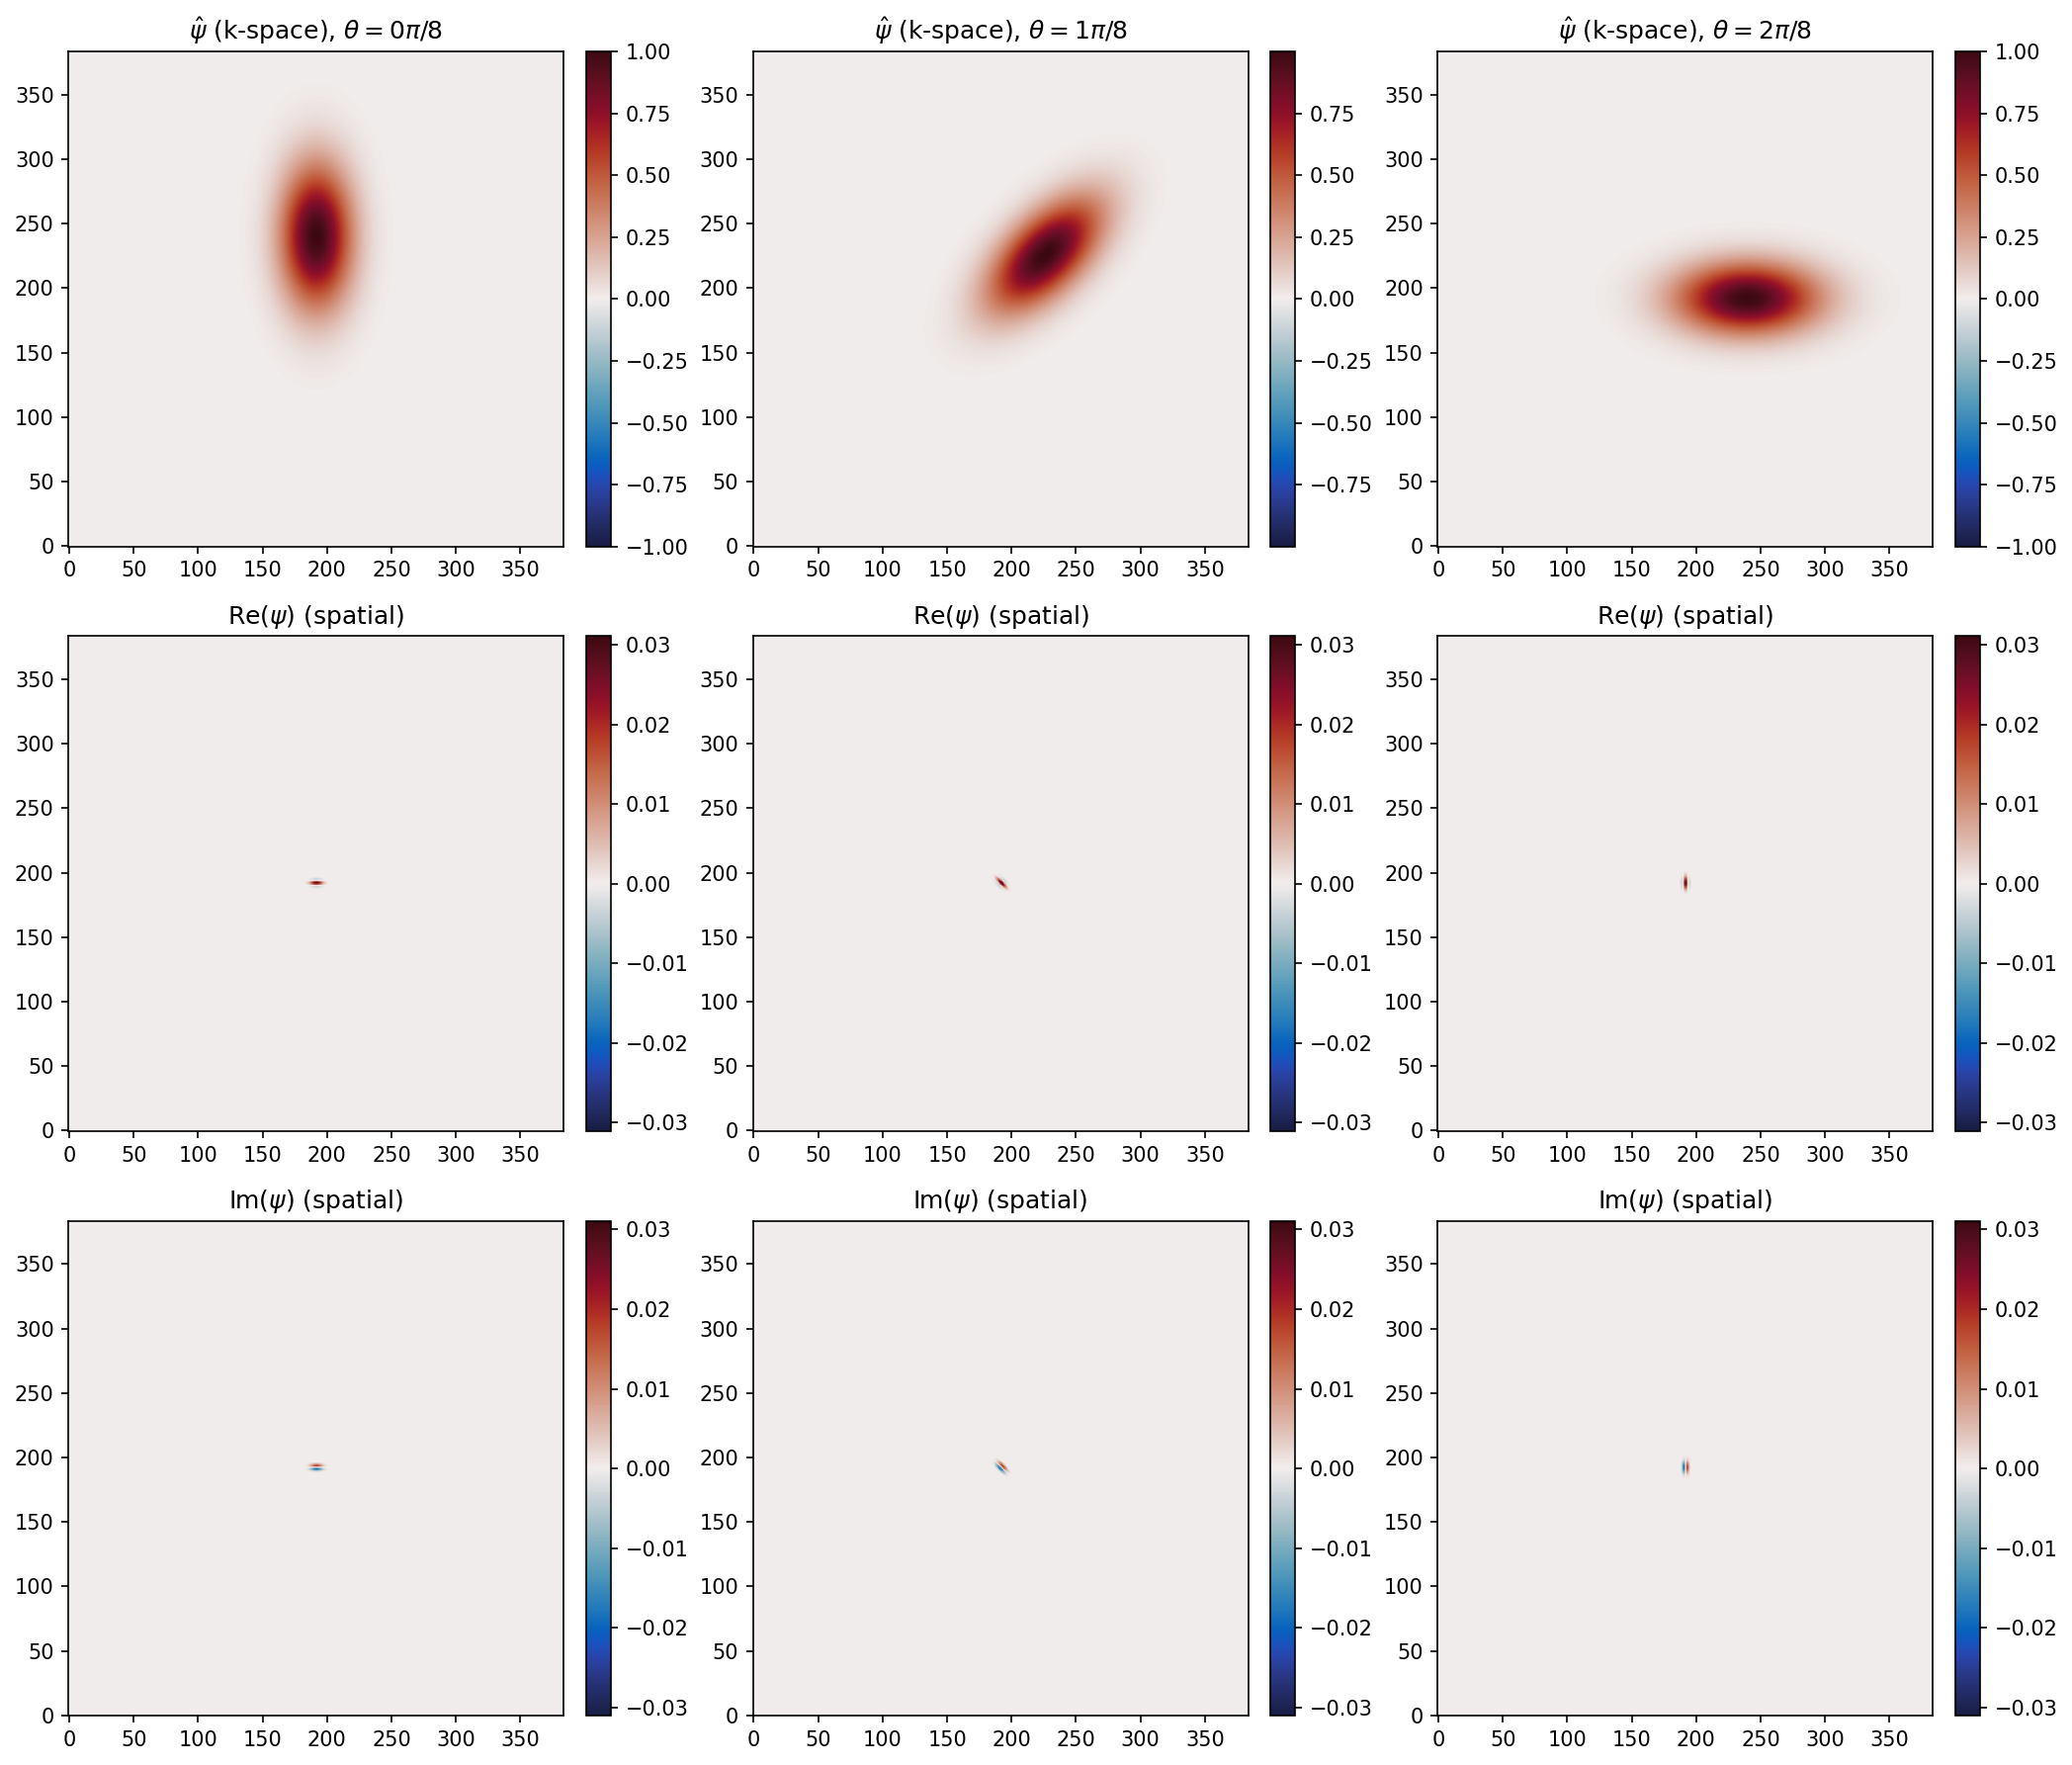

In [35]:
J = 4           # Number of scales
L = 4           # Number of orientations
M, N = 384, 384 # Dimensions of the filter bank in Fourier space (must match the eventual tile size)

# Generate Morlet wavelets
filter_bank = generate_filter_bank(M, N, J=J, L=L, wavelet_type='gabor', sigma0=0.8, xi0=np.pi/4.0)
psi_list = filter_bank['psi']

# Select a scale and a few orientations to visualize
j_vis = 1
l_indices = [0, 1, 2]  # Select multiple orientations (out of L=8)

fig, axes = plt.subplots(3, len(l_indices), figsize=(14, 12))

for col, l in enumerate(l_indices):
    # Extract the specific filter at scale j_vis and orientation l
    for p in psi_list:
        if p['j'] == j_vis and np.isclose(p['theta'], l * np.pi / L):
            psi_f = p['val']
            break
            
    # Transform to spatial domain and center the wavelet peak
    psi_spatial = np.fft.fftshift(np.fft.ifft2(psi_f))
    
    # Plot k-space filter
    ax_k = axes[0, col]
    vmax_k = np.abs(psi_f).max()
    im_k = ax_k.imshow(np.fft.fftshift(psi_f), cmap=cmo.cm.balance, origin='lower', vmin=-vmax_k, vmax=vmax_k)
    ax_k.set_title(rf"$\hat{{\psi}}$ (k-space), $\theta={l}\pi/8$")
    fig.colorbar(im_k, ax=ax_k, fraction=0.046, pad=0.04)
    
    # Plot real spatial part
    ax_real = axes[1, col]
    vmax = np.abs(psi_spatial).max()
    im_real = ax_real.imshow(np.real(psi_spatial), cmap=cmo.cm.balance, origin='lower', vmin=-vmax, vmax=vmax)
    ax_real.set_title(rf"Re($\psi$) (spatial)")
    fig.colorbar(im_real, ax=ax_real, fraction=0.046, pad=0.04)
    
    # Plot imaginary spatial part
    ax_imag = axes[2, col]
    im_imag = ax_imag.imshow(np.imag(psi_spatial), cmap=cmo.cm.balance, origin='lower', vmin=-vmax, vmax=vmax)
    ax_imag.set_title(rf"Im($\psi$) (spatial)")
    fig.colorbar(im_imag, ax=ax_imag, fraction=0.046, pad=0.04)

plt.tight_layout()

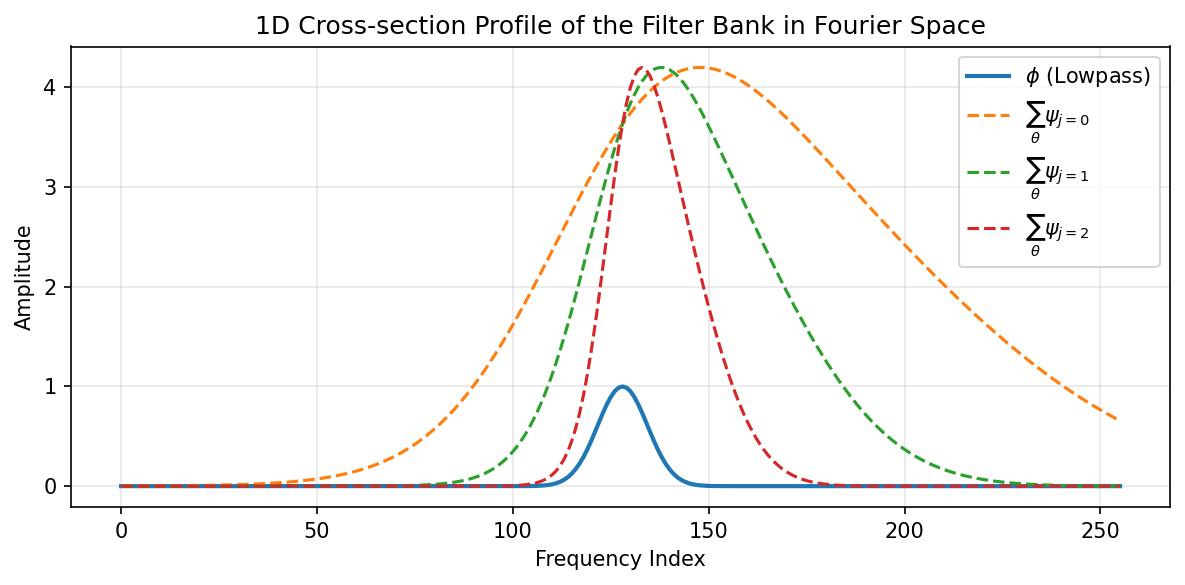

In [7]:
# Plot a 1D symmetric profile (cross-section) of the filters
fig, ax = plt.subplots(figsize=(8, 4))
center = M // 2

# Lowpass profile along the horizontal center slice
phi_val = np.fft.fftshift(filter_bank['phi']['val'])
ax.plot(phi_val[center, :], label=r'$\phi$ (Lowpass)', lw=2)

# Bandpass profiles (sum of all orientations for each scale)
for i_j in range(J):
    psi_j = np.sum([np.fft.fftshift(p['val']) for p in filter_bank['psi'] if p['j'] == i_j], axis=0)
    ax.plot(psi_j[center, :], label=r'$\sum_{\theta} \psi_{j=%d}$' % i_j, ls='--')

ax.set_title("1D Cross-section Profile of the Filter Bank in Fourier Space")
ax.set_xlabel("Frequency Index")
ax.set_ylabel("Amplitude")
ax.legend(loc='upper right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Load PR3 Data & Extract a Test Patch

We'll load the 353 GHz map (`pr3` data block) as used in the `healpix2patch.ipynb` demo and prepare it for analysis by extracting an individual subset of the map. First, we compute the map tiles resolving margins algebraically using `healpix2tiles`.

In [17]:
map_hpx = hp.read_map('HFI_353GHz_IntDR3_NoCMB_NoPS_5arcmin_map-zeroadjust-step3.fits', field=0)
map_patches = tl.healpix2tiles(map_hpx, 2048, 256, 64, margin_method='geometric')
lon = 280.
lat = 90.
f, x, y = map_patches.tile_containing(lon, lat)

patch_data = map_patches.get_tile(f, x, y)

In [25]:
map_hpx = hp.read_map('HFI_353GHz_IntDR3_NoCMB_NoPS_5arcmin_map-zeroadjust-step3.fits', field=0)
map_patches_topo = tl.healpix2tiles(map_hpx, 2048, 256, 64, margin_method='topological')
lon = 280.
lat = 90.
f, x, y = map_patches_topo.tile_containing(lon, lat)

patch_data_topo = map_patches_topo.get_tile(f, x, y)

Apodized Spatial Patch Shape: (384, 384)


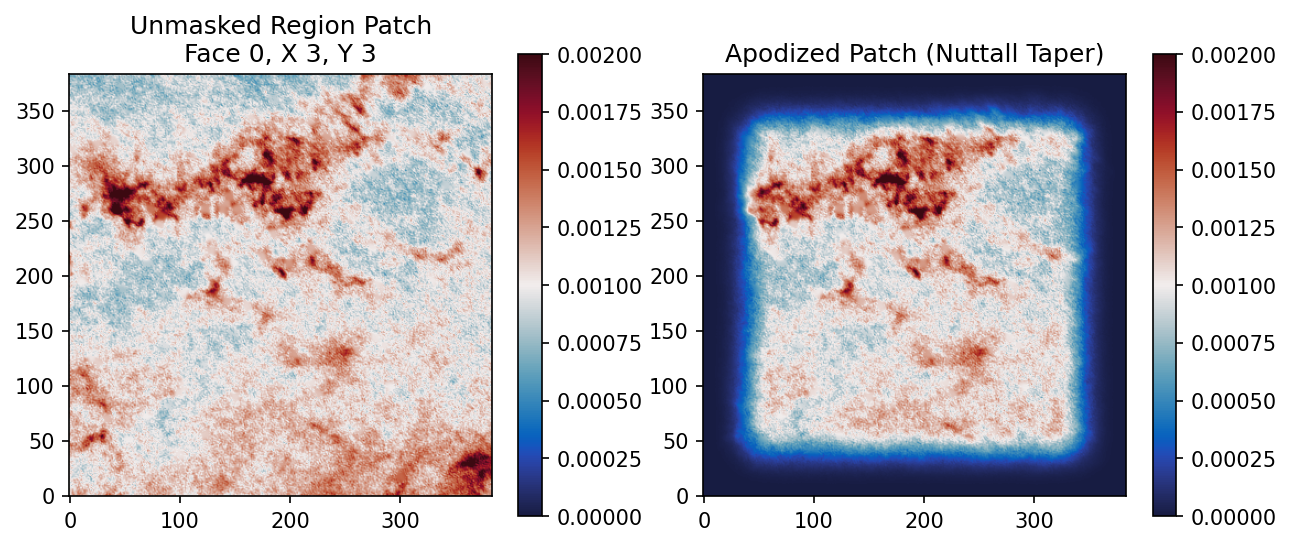

In [ ]:
from skykit.tile_utils import apply_apodization

# Configuration matches PR3 resolution (NSIDE=2048) and chosen tile dimensions
nside = 2048
tile_nside = 256
margin = 64  # Half of spatial gap to provide overlap padding

# Load intensity data
map_hpx = hp.read_map('../data/pr3/HFI_353GHz_IntDR3_NoCMB_NoPS_5arcmin_map-zeroadjust-step3.fits', field=0)
map_patches = tl.healpix2tiles(map_hpx, nside, tile_nside, margin, pol=False)

# Target a tile covering the inner galactic plane where complexity is high
lon, lat = 45.0, 35.0
f, x_idx, y_idx = map_patches.tile_containing(lon, lat)
patch_data = map_patches.get_tile(f, x_idx, y_idx)

# Visualizing before Apodization
fig, ax = plt.subplots(1, 2, figsize=(10, 4), dpi=150)
im = ax[0].imshow(patch_data.T, origin='lower', cmap=cmo.cm.balance, vmin=0., vmax=2e-3)
ax[0].set_title(f"Unmasked Region Patch\nFace {f}, X {x_idx}, Y {y_idx}")
plt.colorbar(im, ax=ax[0])

# We construct and apply an apodized margin to strictly tie spectral noise leakage at boundaries to zero
# apply_apodization operates on the entire TileSet, returning a new filtered TileSet by default.
apodized_patches = apply_apodization(map_patches, taper_type='nuttall', taper_width=margin)
apodized_patch = apodized_patches.get_tile(f, x_idx, y_idx)

im2 = ax[1].imshow(apodized_patch.T, origin='lower', cmap=cmo.cm.balance, vmin=0., vmax=2e-3)
ax[1].set_title("Apodized Patch (Nuttall Taper)")
plt.colorbar(im2, ax=ax[1])

print(f"Apodized Spatial Patch Shape: {apodized_patch.shape}")

## 3. Initialize and Compute the Scattering Transform

We apply the `Scattering2D` transform to our apodized patch. The `transform_tile` will return a dictionary outputting $S_0$, $S_1$, and $S_2$, mapping all spatial structures without frequency decimation (ensuring dimensionality remains `256+2*64 = 384x384`).

In [18]:
scatter = Scattering2D(filter_bank)

# Notice we use `transform_tile` to process one 2D spatial array
coeffs = scatter.transform_tile(patch_data)

print("Scattering Keys:")
print(f"S0: {coeffs['S0'].shape} --> Time averaged invariant energy (Lowpass structure)")
print(f"S1: {coeffs['S1'].shape} --> 1st Order wavelet edges (J * L paths)")
print(f"S2: {coeffs['S2'].shape} --> 2nd Order interacting wavelets")

Scattering Keys:
S0: (384, 384) --> Time averaged invariant energy (Lowpass structure)
S1: (16, 384, 384) --> 1st Order wavelet edges (J * L paths)
S2: (96, 384, 384) --> 2nd Order interacting wavelets


Text(0.5, 1.0, 'Scattering Transform')

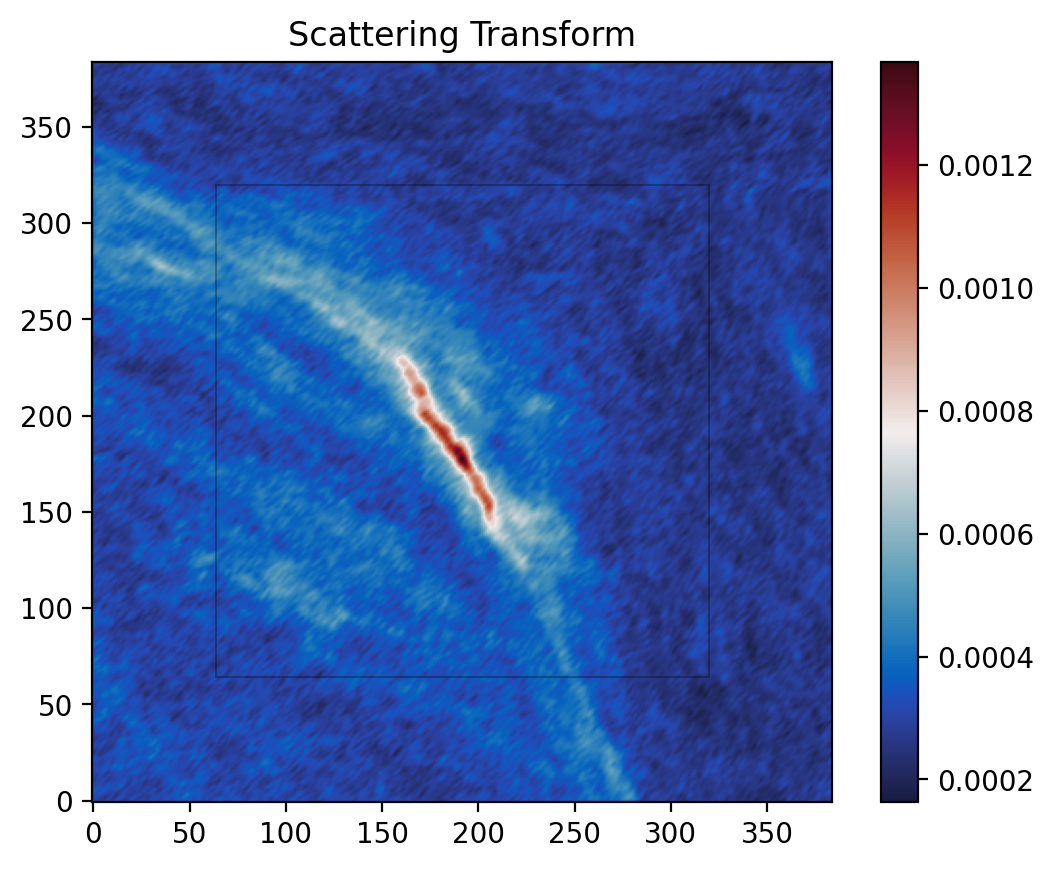

In [33]:
import matplotlib.patches as patches

fig, ax = plt.subplots(dpi=200)
im = ax.imshow(coeffs['S1'][3], cmap=cmo.cm.balance, origin='lower')
plt.colorbar(im)

# Overlay a box to delineate the interior pixels (256x256) from the exterior margin (128px borders)
margin = map_patches.margin
tile_nside = map_patches.tile_nside
rect = patches.Rectangle((margin, margin), tile_nside, tile_nside, linewidth=0.7, edgecolor='k', facecolor='none', linestyle='-', alpha=0.3)
ax.add_patch(rect)
ax.set_title("Scattering Transform")

In [26]:
scatter = Scattering2D(filter_bank)

# Notice we use `transform_tile` to process one 2D spatial array
coeffs_topo = scatter.transform_tile(patch_data_topo)

print("Scattering Keys:")
print(f"S0: {coeffs['S0'].shape} --> Time averaged invariant energy (Lowpass structure)")
print(f"S1: {coeffs['S1'].shape} --> 1st Order wavelet edges (J * L paths)")
print(f"S2: {coeffs['S2'].shape} --> 2nd Order interacting wavelets")

Scattering Keys:
S0: (384, 384) --> Time averaged invariant energy (Lowpass structure)
S1: (16, 384, 384) --> 1st Order wavelet edges (J * L paths)
S2: (96, 384, 384) --> 2nd Order interacting wavelets


Text(0.5, 1.0, 'Scattering Transform')

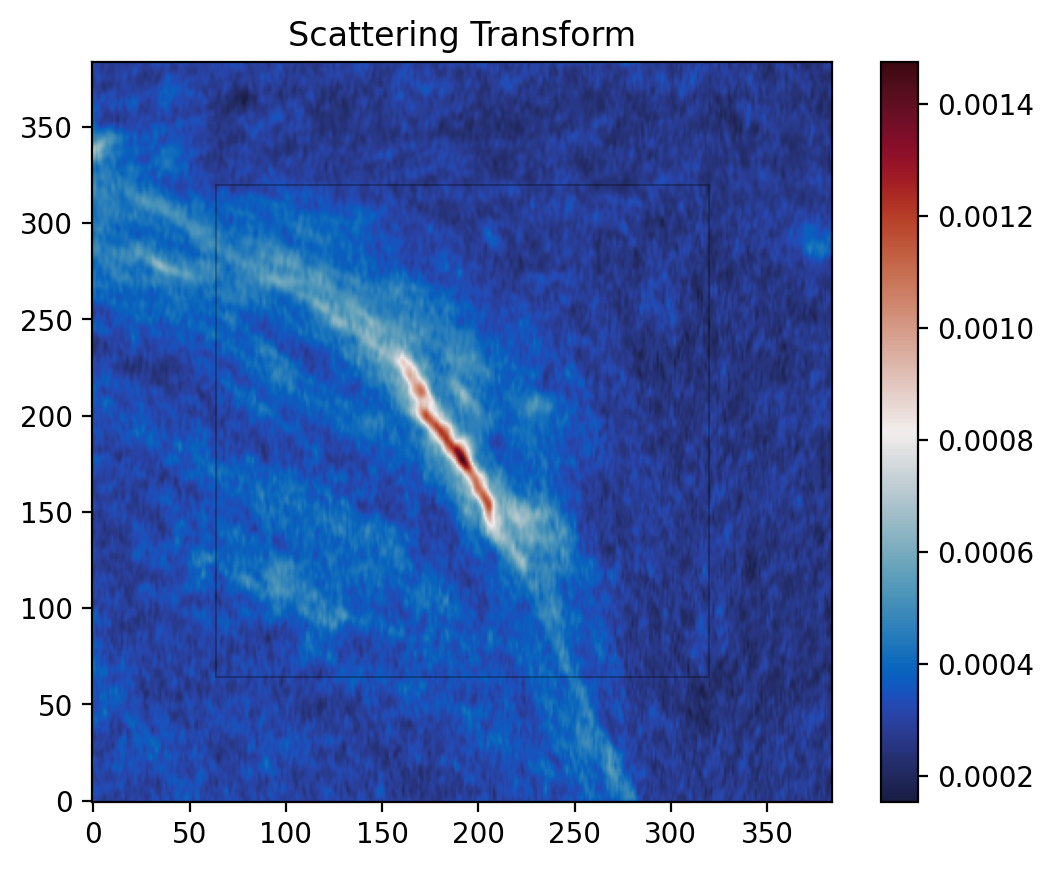

In [36]:
import matplotlib.patches as patches

fig, ax = plt.subplots(dpi=200)
im = ax.imshow(coeffs_topo['S1'][2], cmap=cmo.cm.balance, origin='lower')
plt.colorbar(im)

# Overlay a box to delineate the interior pixels (256x256) from the exterior margin (128px borders)
margin = map_patches.margin
tile_nside = map_patches.tile_nside
rect = patches.Rectangle((margin, margin), tile_nside, tile_nside, linewidth=0.7, edgecolor='k', facecolor='none', linestyle='-', alpha=0.3)
ax.add_patch(rect)
ax.set_title("Scattering Transform")

## 4. Visualize Spatial Coefficient Maps ($S_1$)

We can use the `plot_scattering_coefs` wrapper (or manual indexing) to plot the un-decimated spatial scattering maps. Since the maps maintain exactly 1:1 pixel coverage to the $384 \times 384$ tile, structural relations are trivial to compare.

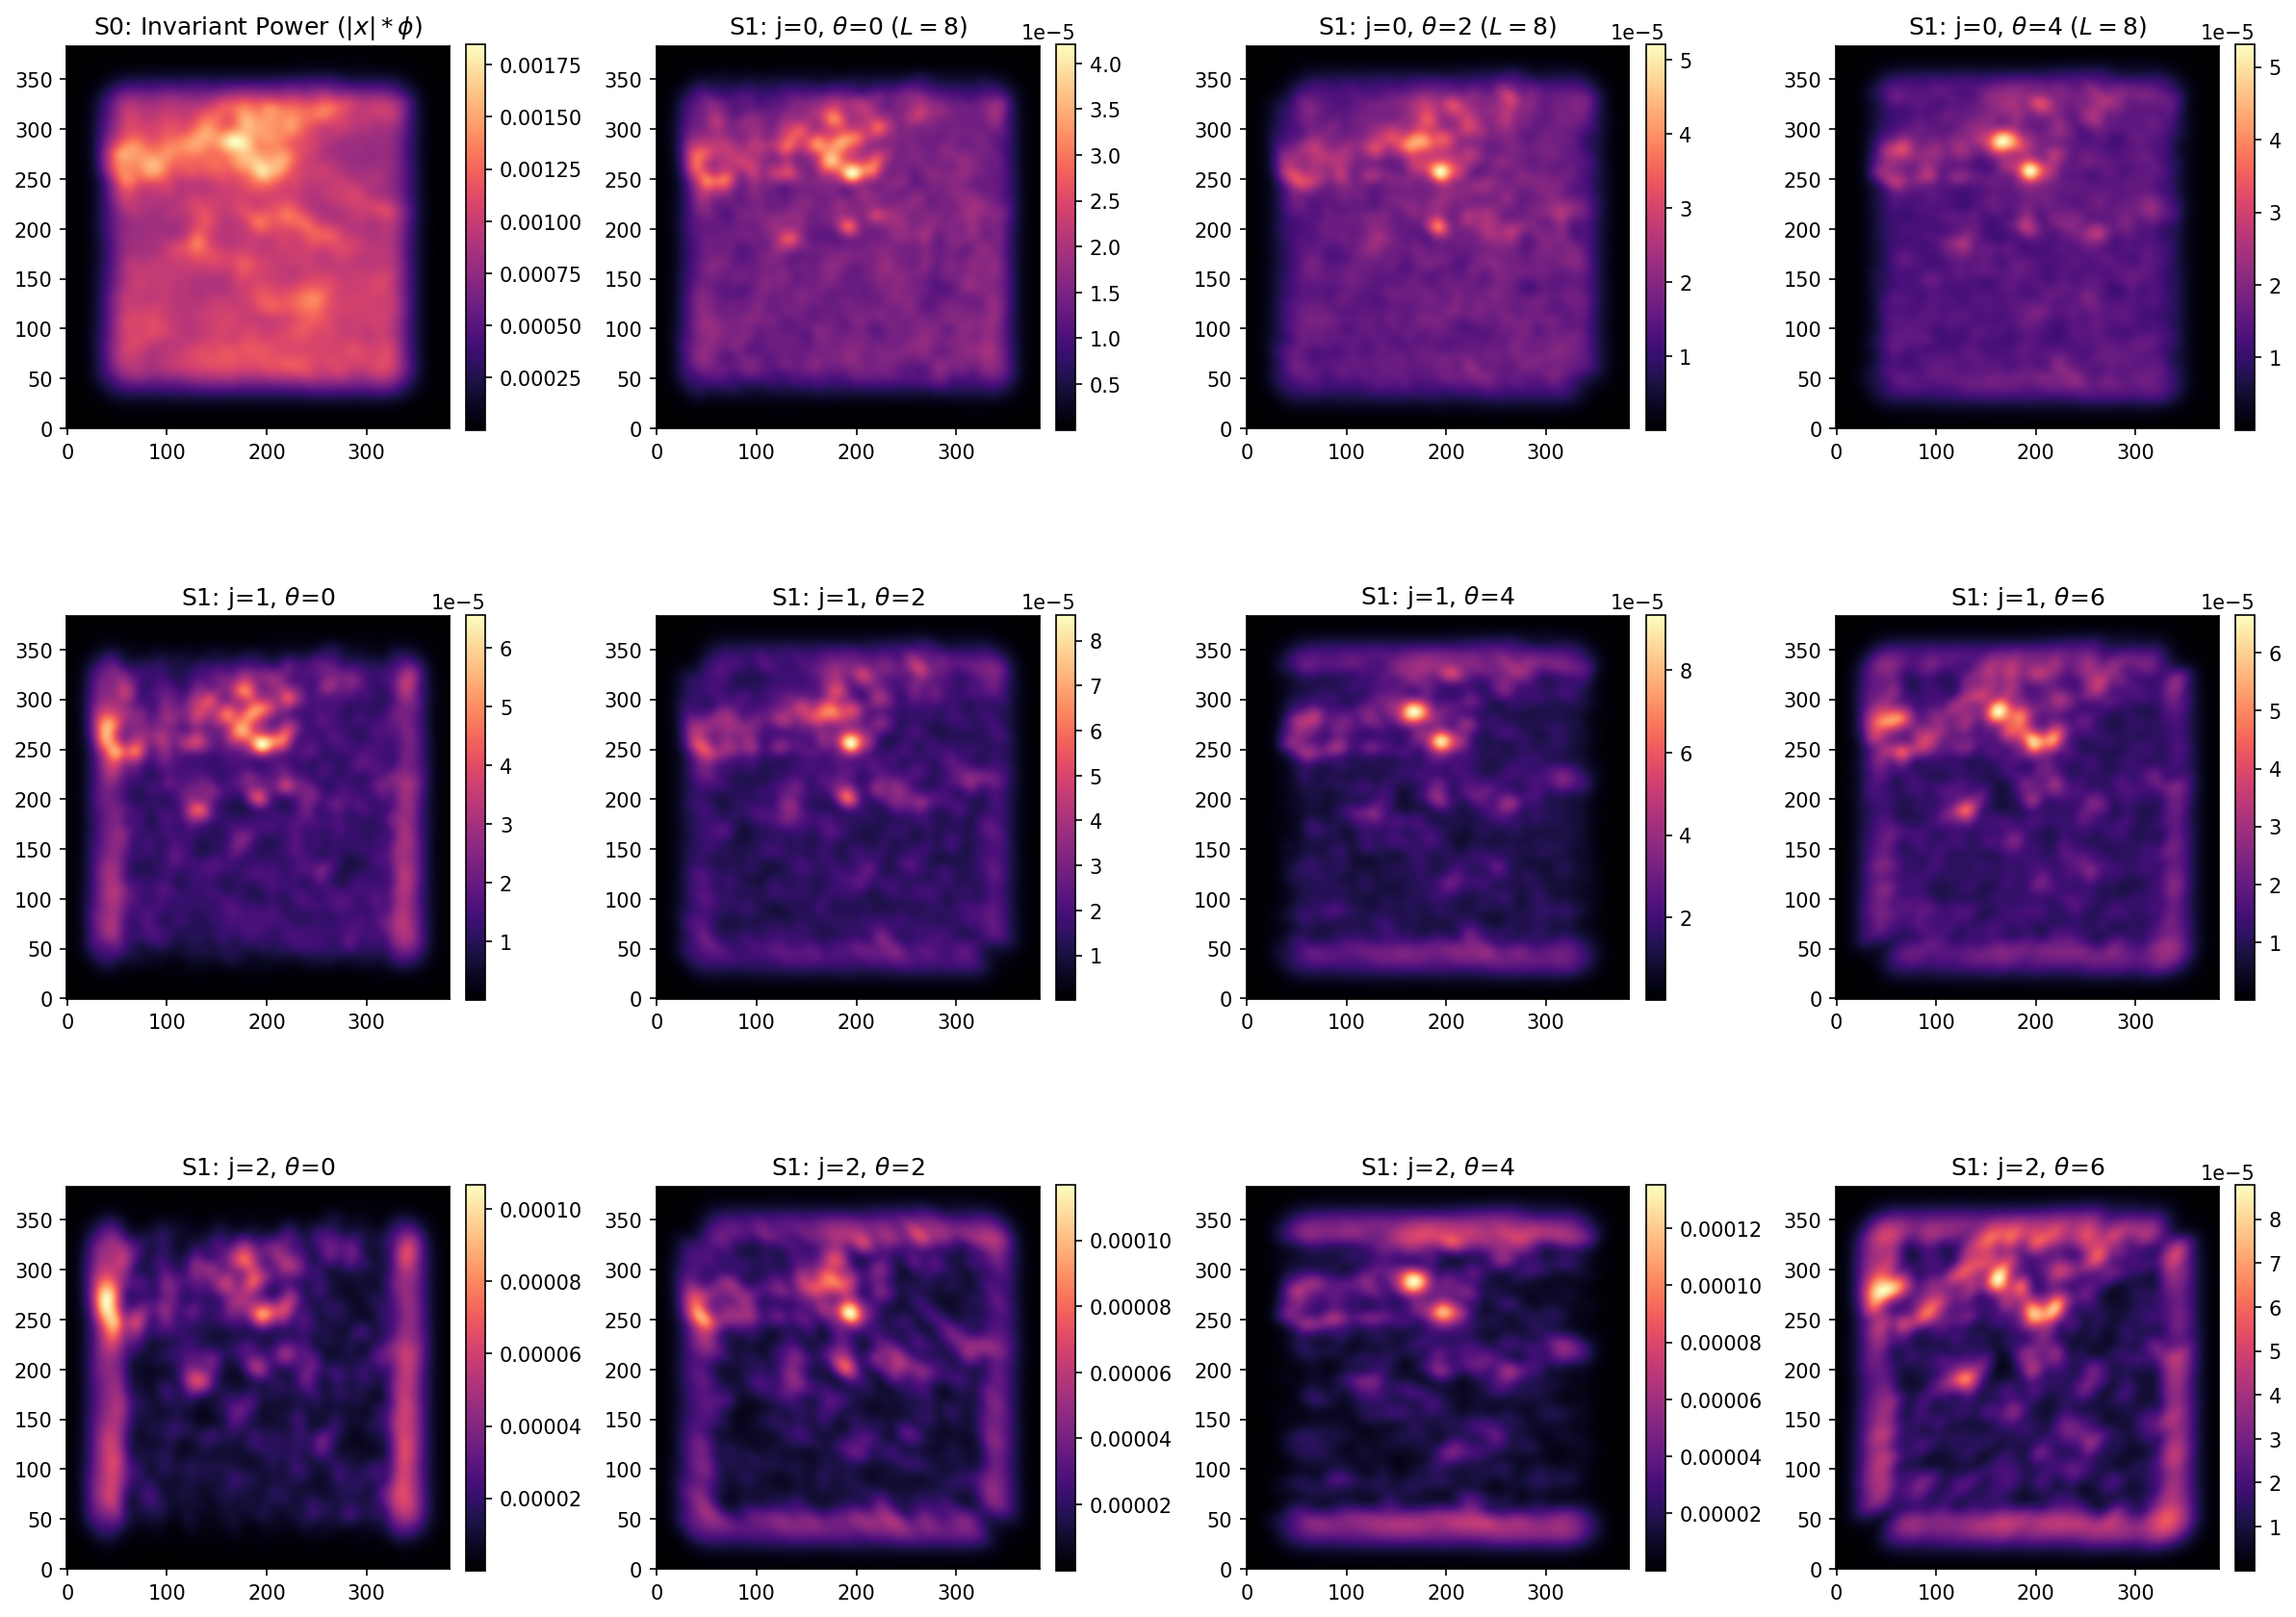

In [9]:
fig, axes = plt.subplots(3, 4, figsize=(16, 12))

# Plot the base $S_0$ component (Pure Lowpass Phi)
im0 = axes[0, 0].imshow(coeffs['S0'].T, origin='lower', cmap='magma')
axes[0, 0].set_title(r"S0: Invariant Power ($|x| * \phi$)")
plt.colorbar(im0, ax=axes[0, 0], fraction=0.046, pad=0.04)

# We will plot S_1 for the first scale (j=0) across 3 angles
for idx, orient in enumerate([0, 2, 4]):
    ax = axes[0, idx + 1]
    im = ax.imshow(coeffs['S1'][orient].T, origin='lower', cmap='magma')
    ax.set_title(f"S1: j=0, $\\theta$={orient} ($L=8$)")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# Plot S_1 for the second scale (j=1)
for idx, orient in enumerate([0, 2, 4, 6]):
    ax = axes[1, idx]
    im = ax.imshow(coeffs['S1'][L + orient].T, origin='lower', cmap='magma')
    ax.set_title(f"S1: j=1, $\\theta$={orient}")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# Plot S_1 for the third scale (j=2)
for idx, orient in enumerate([0, 2, 4, 6]):
    ax = axes[2, idx]
    im = ax.imshow(coeffs['S1'][2*L + orient].T, origin='lower', cmap='magma')
    ax.set_title(f"S1: j=2, $\\theta$={orient}")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()

## 5. Calculate and Evaluate Global Scattering Coefficients

A key step for machine learning or covariance matrices is spatial pooling. For scalar map patches, this transforms $S_1$ and $S_2$ pixel arrays into a fixed array of single values. In practice, the zero-padded margins mean the window is strictly zero at boundaries—we merely average across the valid interior (if desired) or simple global average.

We evaluate the $S(j, \theta)$ representations grouped appropriately.

Number of S1 Paths: 24
Number of S2 Paths: 192


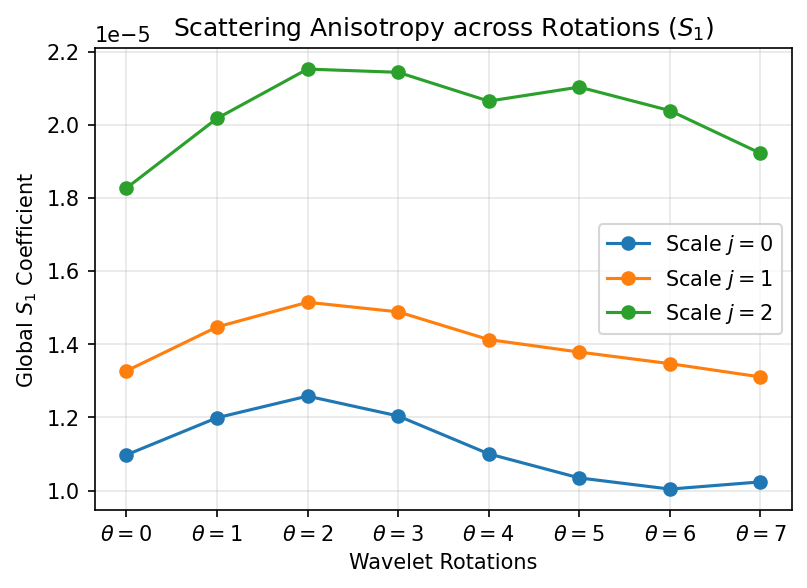

In [10]:
# Global Spatial Log-Averaging
S0_coeff = coeffs['S0'].mean()
S1_coeffs = np.array([x.mean() for x in coeffs['S1']])
S2_coeffs = np.array([x.mean() for x in coeffs['S2']])

print(f"Number of S1 Paths: {len(S1_coeffs)}")
print(f"Number of S2 Paths: {len(S2_coeffs)}")

# We can plot S1 vs (scale, angle) to check the structural alignment
fig, ax = plt.subplots(figsize=(6, 4))

angle_indices = np.arange(L)
s1_reshape = S1_coeffs.reshape(J, L)

for j in range(J):
    ax.plot(angle_indices, s1_reshape[j, :], marker='o', label=f"Scale $j={j}$")

ax.set_xticks(angle_indices)
ax.set_xticklabels([f"$\\theta={i}$" for i in range(L)])
ax.set_xlabel("Wavelet Rotations")
ax.set_ylabel("Global $S_1$ Coefficient")
ax.grid(alpha=0.3)
ax.set_title("Scattering Anisotropy across Rotations ($S_1$)")
ax.legend()
plt.show()